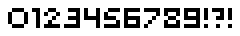

In [12]:
from PIL import Image, ImageDraw

# dreamstime.com
GLYPHS = {
    'A': ["0010", "0101","1001", "1111", "1001"],
    'B': ["1100", "1010","1110", "1001", "1110"],
    'C': ["0100", "1010","1000", "1001", "0110"],
    'D': ["1100", "1010","1001", "1001", "1110"],
    'E': ["0110", "1000","1111", "1000", "0111"],
    'F': ["0110", "1000","1111", "1000", "1000"],
    'G': ["0110", "1000","1011", "1001", "1110"],
    'H': ["0001", "1001","1001", "1111", "1001"],
    'I': ["111", "010","010", "010", "111"],
    'J': ["0011", "0001","0001", "1001", "0110"],
    'K': ["1010", "1100","1010", "1001", "1001"],
    'L': ["1000", "1000","1000", "1001", "1111"],
    'M': ["11000", "10110","10101", "10101", "10101"],
    'N': ["1001", "1101","1011", "1001", "1001"],
    'O': ["0110", "1001","1001", "1001", "0110"],
    'P': ["1110", "1001","1111", "1000", "1000"],
    'Q': ["01100", "10010","10010", "10110", "01101"],
    'R': ["1100", "1010","1110", "1001", "1001"],
    'S': ["0110", "1000","0110", "0001", "1110"],
    'T': ["111", "010","010", "010", "010"],
    'U': ["0001", "1001","1001", "1001", "0110"],
    'V': ["0001", "1001","1001", "1010", "0100"],
    'W': ["00001", "10101","10101", "10101", "01010"],
    'X': ["0001", "1001","1001", "0110", "1001"],
    'Y': ["0001", "1001","0111", "0001", "0110"],
    'Z': ["1111", "0001","0110", "1000", "1111"],
    
    '0': ["0111", "1001","1001", "1001", "1110"],
    '1': ["110", "010","010", "010", "111"],
    '2': ["0110", "0001","0110", "1000", "1111"],
    '3': ["0110", "0001","0110", "0001", "1110"],
    '4': ["1001", "1001","0111", "0001", "0001"],
    '5': ["1110", "1000","1110", "0001", "1110"],
    '6': ["0110", "1000","1110", "1001", "0110"],
    '7': ["1111", "0001","0010", "0100", "0100"],
    '8': ["1110", "1001","0110", "1001", "0111"],
    '9': ["1110", "1001","0111", "0001", "1110"],

    '%': ["1001", "1001","0010", "0100", "1001"],
    '.': ["0", "0","0", "0", "1"],
    ',': ["00", "00","00", "01", "10"],
    '!': ["1", "1","1", "0", "1"],
    '?': ["110", "001","010", "000", "010"],
    ' ': ["00", "00","00", "00", "00"],
}

# visalettersapplication.com
GLYPHS = {
    'A': ["001111", "011111", "111011", "110011", "111111", "111111", "110011", "110011", "110011"],
    'B': ["111110", "111111", "110111", "110011", "111110", "110011", "110111", "111111", "111110"],
    'C': ["011111", "111111", "111011", "110000", "110000", "110000", "111011", "111111", "011111"],
    'D': ["111110", "111111", "110111", "110011", "110011", "110011", "110111", "111111", "111110"],
    'E': ["011111", "111111", "110000", "111111", "111111", "110000", "110000", "111111", "011111"],
    'F': ["011111", "111111", "110000", "110000", "111110", "111110", "110000", "110000", "110000"],
    'G': ["011110", "111111", "110111", "110011", "110000", "110111", "110011", "111111", "011110"],
    'H': ["110011", "110011", "110011", "110011", "111111", "111111", "110011", "110011", "110011"],
    'I': ["1111", "1111", "0110", "0110", "0110", "0110", "0110", "1111", "1111"],
    'J': ["000011", "000011", "000011", "000011", "000011", "000011", "110011", "111111", "011110"],
    'K': ["110011", "110011", "110111", "111110", "111100", "111111", "110111", "110011", "110011"],
    'L': ["110000", "110000", "110000", "110000", "110000", "110000", "110011", "111111", "111111"],
    'M': ["01100110", "111111", "1111111", "11011011", "11011011", "11011011", "11011011", "11011011", "11011011"],
    'N': ["110011", "110011", "111011", "111011", "111111", "111111", "110111", "110011", "110011"],
    'O': ["011110", "111111", "110011", "110011", "110011", "110011", "110011", "111111", "011110"],
    'P': ["011110", "111111", "110011", "110011", "111111", "111110", "110000", "110000", "110000"],
    'Q': ["0111100", "1111110", "1100110", "1100110", "1100110", "1100110", "1101111", "1111111", "0111100"],
    'R': ["011110", "111111", "110011", "110011", "111111", "111110", "110111", "110011", "110011"],
    'S': ["011111", "111111", "110000", "111000", "111111", "001111", "000011", "111111", "111110"],
    'T': ["111111", "111111", "001100", "001100", "001100", "001100", "001100", "001100", "001100"],
    'U': ["110011", "110011", "110011", "110011", "110011", "110011", "110011", "111111", "111111"],
    'V': ["110011", "110011", "110011", "110011", "110011", "110011", "110011", "111111", "011110"],
    'W': ["11011011", "11011011", "11011011", "11011011", "11011011", "11011011", "11111111", "11111111", "01100110"],
    'X': ["110011", "110011", "111111", "011110", "001100", "011110", "111111", "110011", "110011"],
    'Y': ["110011", "110011", "110011", "111111", "011110", "001100", "001100", "001100", "001100"],
    'Z': ["111111", "111111", "000111", "001110", "011110", "011100", "111000", "111111", "111111"],

    
    '0': ["011111", "111111", "110011", "110011", "110011", "110011", "110011", "111111", "111111"],
    '1': ["111100", "011100", "001100", "001100", "001100", "001100", "001100", "111111", "111111"],
    '2': ["111111", "111111", "000011", "000011", "011111", "111111", "110000", "111111", "111111"],
    '3': ["111110", "111111", "000111", "000011", "111111", "111111", "000011", "111111", "111110"],
    '4': ["110011", "110011", "110011", "111111", "011111", "000011", "000011", "000011", "000011"],
    '5': ["111111", "111111", "110000", "111110", "111111", "000011", "000011", "111111", "111110"],
    '6': ["111111", "111111", "110000", "111111", "111111", "110011", "110011", "111111", "111110"],
    '7': ["111110", "111111", "000111", "000011", "000011", "000011", "000011", "000011", "000011"],
    '8': ["011110", "111111", "110011", "110011", "011110", "110011", "110011", "111111", "011110"],
    '9': ["011111", "111111", "110011", "110011", "111111", "111111", "000011", "111111", "111110"],
    
    # '%': ["1001", "1001","0010", "0100", "1001"],
    # '.': ["0", "0","0", "0", "1"],
    # ',': ["00", "00","00", "01", "10"],
    # '!': ["1", "1","1", "0", "1"],
    # '?': ["110", "001","010", "000", "010"],
    ' ': ["00", "00","00", "00", "00", "00","00", "00", "00"],
}


# fontmeme.com
GLYPHS = {
    'A': ["00000", "10001","11111", "10001", "10001"],
    'B': ["11110", "10001","11111", "10001", "11110"],
    'C': ["11111", "10000","10000", "10000", "11111"],
    'D': ["11110", "10001","10001", "10001", "11110"],
    'E': ["11111", "10000","11110", "10000", "11111"],
    'F': ["11111", "10000","11110", "10000", "10000"],
    'G': ["11111", "10000","10111", "10001", "11111"],
    'H': ["10001", "10001","11111", "10001", "10001"],
    'I': ["11111", "00100","00100", "00100", "11111"],
    'J': ["1111", "0001","0001", "1010", "1110"],
    'K': ["1001", "1010","1100", "1010", "1001"],
    'L': ["10000", "10000","10000", "10000", "11111"],
    'M': ["10001", "11011","10101", "10001", "10001"],
    'N': ["10001", "11001","10101", "10011", "10001"],
    'O': ["11111", "10001","10001", "10001", "11111"],
    'P': ["11111", "10001","11111", "10000", "10000"],
    'Q': ["11111", "10001","10001", "10011", "11111"],
    'R': ["11111", "10001","11111", "10010", "10001"],
    'S': ["11111", "10000","11111", "00001", "11111"],
    'T': ["11111", "00100","00100", "00100", "00100"],
    'U': ["10001", "10001","10001", "10001", "11111"],
    'V': ["10001", "10001","01010", "01010", "00100"],
    'W': ["10001", "10001","10101", "11011", "10001"],
    'X': ["10001", "01010","00100", "01010", "10001"],
    'Y': ["10001", "01010","00100", "00100", "00100"],
    'Z': ["11111", "00010","00100", "01000", "11111"],
    
    '0': ["01110", "10001","10001", "10001", "01110"],
    '1': ["11", "01","01", "01", "01"],
    '2': ["0110", "1001","0010", "0100", "1111"],
    '3': ["0111", "0001","0111", "0001", "1111"],
    '4': ["1001", "1001","1111", "0001", "0001"],
    '5': ["0111", "1000","1110", "0001", "1111"],
    '6': ["1111", "1000","1111", "1001", "1111"],
    '7': ["1111", "0001","0010", "0100", "1000"],
    '8': ["1111", "1001","0110", "1001", "1111"],
    '9': ["1111", "1001","1111", "0001", "1111"],

    '.': ["1", "1","1", "0", "1"],
    '!': ["1", "1","1", "0", "1"],
    '?': ["111", "001", "011", "000", "010"],
    ' ': ["00", "00","00", "00", "00"],
}


SCALE    = 4   # pixels per dot
GAP      = 1   # dot-columns between letters
LINE_GAP = 1   # dot-rows between lines
PAD      = 2   # border padding in dots


def text_to_image(text, fg=(0,0,0), bg=(255,255,255)):
    lines = text.upper().split('\n')

    # Replace unknown chars with space
    glyph_lines = [
        [GLYPHS.get(c, GLYPHS[' ']) for c in line]
        for line in lines
    ]

    line_heights = [max(len(g) for g in line) for line in glyph_lines]
    line_widths  = [
        sum(len(g[0]) for g in line) + GAP * (len(line) - 1)
        for line in glyph_lines
    ]

    total_w = (max(line_widths) + PAD * 2) * SCALE
    total_h = (sum(line_heights) + LINE_GAP * (len(glyph_lines) - 1) + PAD * 2) * SCALE

    img  = Image.new("RGB", (total_w, total_h), bg)
    draw = ImageDraw.Draw(img)

    y_origin = PAD * SCALE
    for line_i, glyphs in enumerate(glyph_lines):
        line_h = line_heights[line_i]
        x_origin = PAD * SCALE
        for glyph in glyphs:
            for row_i, row in enumerate(glyph):
                for bit_i, bit in enumerate(row):
                    if bit == '1':
                        x = x_origin + bit_i * SCALE
                        y = y_origin + row_i * SCALE
                        draw.rectangle([x, y, x+SCALE-1, y+SCALE-1], fill=fg)
            x_origin += (len(glyph[0]) + GAP) * SCALE

        y_origin += (line_h + LINE_GAP) * SCALE

    return img
img = text_to_image("HELLO \n  WILLI!")
img = text_to_image("0123456789!?.")
img

![](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse1.mm.bing.net%2Fth%2Fid%2FOIP.bSJtLklhUqZl0vWhsghmnwHaGQ%3Fpid%3DApi&f=1&ipt=67ce06a2962b577b0cf4ffca9cc20ef1908b3e87a836dd37a7b96f76258ab574&ipo=images)